# Code Assignment 16 — K-Means Clustering (Mall Customers, 2–3 Features Only)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **K-Means** clustering model using **only 2–3 simple numeric features** with **minimal cleaning**, pick **K** via **Elbow + Silhouette** on the **train split**, and sanity-check **generalization** on the **test split**. Then profile clusters in plain business terms.

**Dataset (simple, non-transportation):** *Mall Customers* (public, widely used teaching dataset)  

> We will only use **2–3 numeric columns**: e.g., `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.  



## Instructor Guidance (Pseudocode + Docs)

**Docs:**  
- `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

### Pseudocode Plan (Minimal)
1) **Load CSV** → preview columns/shape.  
2) **Pick 2–3 numeric features** (e.g., Age, Income, SpendingScore).  
3) **Drop NA only** on those columns.  
4) **Split**: `train_test_split(X, test_size=0.2, random_state=42)`.  
5) **Scale**: `StandardScaler` — **fit on TRAIN**, transform TRAIN and TEST.  
6) **Choose K** on TRAIN: loop K=2..8 → plot **Elbow (inertia)** and **Silhouette**.  
7) **Fit final KMeans** on TRAIN with your chosen K; predict TRAIN & TEST labels.  
8) **Sanity check**: report **Silhouette (TRAIN vs TEST)**.  
9) **Profile clusters**: per-cluster means of your 2–3 features (no extra cleaning).  
10) **Reflection**: justify K, describe segments, suggest one action per segment.


## Your Task — Step-by-Step
Work in pairs. Keep code minimal. Use only 2–3 features.

### 1) Imports & Settings

In [25]:
import pandas as pd
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import k_means, KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import dataprep
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score



### 2) Load the Mall Customers CSV & Preview

In [10]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/Mall_Customers copy.csv')
print(df.shape)

df.isnull().sum()
#df.head(10)
df.dtypes

(200, 5)


CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

### 3) Select **2–3 Numeric Features** (no heavy cleaning)
Choose from:
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

> Keep it simple: e.g., use **Age + Spending Score** (2D) or **Age + Income + Spending Score** (3D).


In [15]:
Xs = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

### 4) Train–Test Split (for model generalization sanity check)

In [ ]:
X_train, X_test = train_test_split(Xs, test_size=0.4, random_state=42) # no response variable needed 'y' because it is unsupervised learning

### 5) Scale (fit on TRAIN only), then Explore K on TRAIN (Elbow + Silhouette)

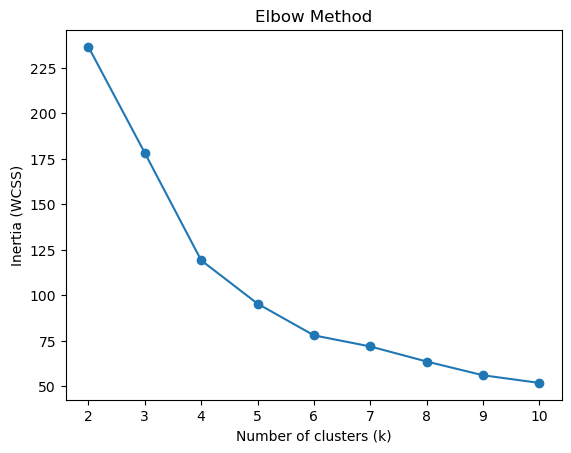

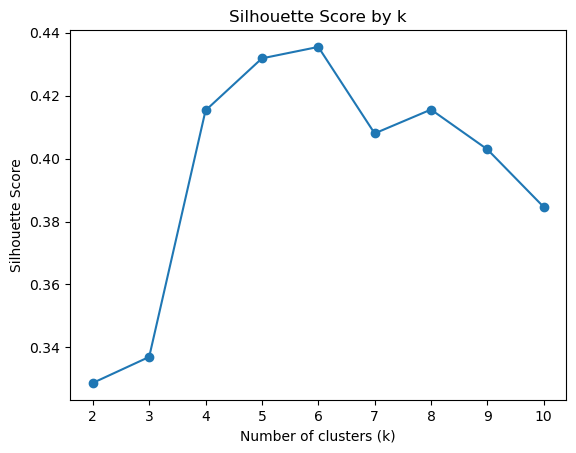

In [ ]:
scaler = StandardScaler()
Xs_scaled = scaler.fit_transform(X_train)


# elbow method, to visually see the best k, the point that looks like an elbow is the best number of cluster, but this is not precise
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(Xs_scaled)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()
# silhouette method, narrowing down the search, to peak at the best k, using a score, not just visually
sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(Xs_scaled)
    score = silhouette_score(Xs_scaled, labels)
    sil_scores.append(score)

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.show()



### 6) Choose **K** (justify), Fit Final Model on TRAIN, Check Stability on TEST
- Report **Silhouette TRAIN vs TEST** (higher is better; similar values suggest stability).

In [41]:
k = 6 # based on the elbow and silhouette methods, 6 seemed to be the best compromise

Kmeans = KMeans(n_clusters=k, random_state= 0, n_init=10)
model = Kmeans.fit(Xs_scaled)



In [ ]:
# preparing x_test by scaling it
Xs_test_scaled = scaler.fit_transform(X_test)

# score for the train silhouette
train_sil = silhouette_score(Xs_scaled, model.labels_)

# assign test point to my test data, enabling to compute its score
test_labels = model.predict(Xs_test_scaled)

# computing test silhouette score on the test data
test_sil = silhouette_score(Xs_test_scaled, test_labels)

print("Train Silhouette Score:", train_sil)
print("Test Silhouette Score:", test_sil)


Train Silhouette Score: 0.4330743605090555
Test Silhouette Score: 0.43014191433634713


### 7) Profile Clusters (Business-Readable)
- Use the **original (unscaled)** features for interpretation.
- Show per-cluster means of your **2–3 features**.

Cluster Profiles (mean values per cluster):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        32.384615           86.230769               83.615385
1        43.692308           25.076923               16.615385
2        57.785714           53.678571               48.357143
3        27.857143           57.285714               44.333333
4        25.600000           24.800000               74.866667
5        41.705882           96.058824               19.470588


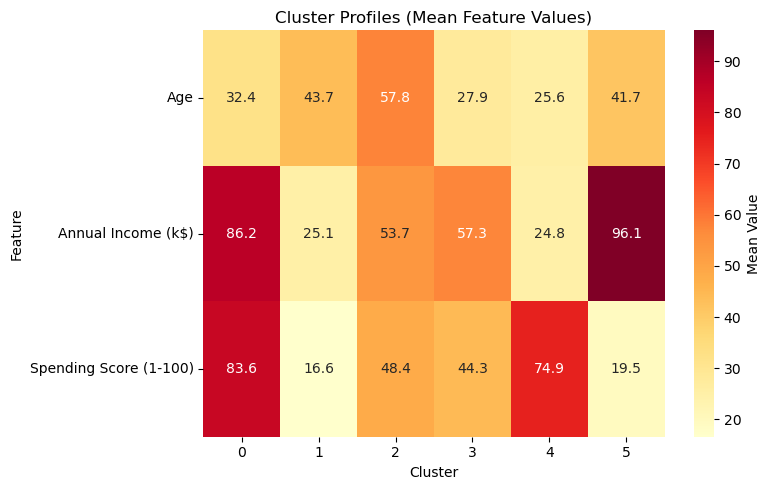

In [50]:
# Adding the clusters label from the model to my original dataset, so each point knows in which cluster it belongs [0-5]
X_train['Cluster'] = model.labels_

# computing the mean for each cluster
cluster_profiles = X_train.groupby('Cluster').mean()

print("Cluster Profiles (mean values per cluster):")
print(cluster_profiles)

# plotting the profiles in a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_profiles.T, # T for transposing for better readability
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Value'}
)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.title('Cluster Profiles (Mean Feature Values)')
plt.tight_layout()
plt.show()

## We Share — Reflection (2 short paragraphs)

1) **K choice & stability:** What **K** did you choose and why (Elbow bend, Silhouette peak/plateau, simplicity)? Report **Silhouette (TRAIN vs TEST)** — did structure persist, or did it collapse on test?  

after using the elbow method which roughly indicates the best number of clusters [4,6], I followed with the silhouette score which was more precise and peaked at 6. I therefore segmented my profiles into 6 categories labeled 0,1,2,3,4,5
the silhouette score on my train was 0.433 vs 0.430 for my test, indicating good model generalization. The structure persisted
2) **Segments & actions:** Give short names to your segments (e.g., “Young High-Spend,” “Mid-Age Value-Seeker,” “Older Low-Spend”) and suggest **one actionable idea** for each (targeted offers, product mix, messaging).

- **segment-0**: Mid_age wealthy and high spend : Offers coupon for customer loyalty for the long term, as relatively young, high income, high spend
- **segment-1**: Mid age low income low spend : messaging, propose special discount to motivate spending, as low income and low spending
- **segment-2**: Older high potential clients : high potential clients, product mix can enhance 
- **segment-3**: Young value seeker : Young, high product variabilty recommended to enhance purchases, financially stable
- **segment-4**: high spend low income young: very high potential clients, low income but high spending score, marketing promo to loyalize them
- **segment-5**: Volatile wealthy clients: wealthy, mid age, poor spend. messaging, tailoring and targeting offers

> Bonus: Re-run with **just 2 features** (e.g., **Income + SpendingScore**) and compare stability & interpretability.


Train Silhouette Score: 0.5572859841915894
Test Silhouette Score: 0.5513784812022615
Cluster Profiles (mean values per cluster):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.928571           24.357143               18.214286
1        45.510638           53.595745               48.851064
2        25.692308           24.461538               78.692308
3        32.384615           86.230769               83.615385
4        40.200000           92.950000               19.050000


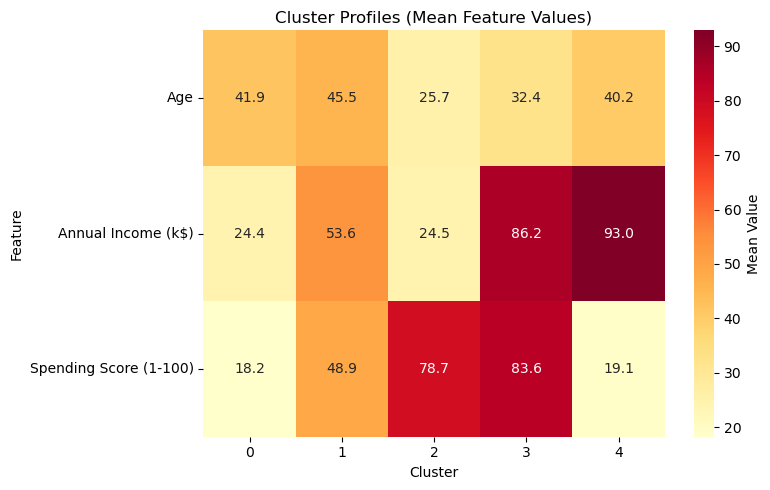

In [59]:
# cheking model with only two features

X_train2_unscaled = X_train[['Annual Income (k$)','Spending Score (1-100)']]
X_test2_unscaled = X_test[['Annual Income (k$)','Spending Score (1-100)']]

# Scale the 2-feature subsets
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2_unscaled)
X_test2 = scaler2.transform(X_test2_unscaled)

k = 5 # based on the elbow and silhouette methods, 6 seemed to be the best compromise

Kmeans = KMeans(n_clusters=k, random_state= 0, n_init=10)
model = Kmeans.fit(X_train2)


# score for the train silhouette
train_sil = silhouette_score(X_train2, model.labels_)

# assign test point to my test data, enabling to compute its score
test_labels = model.predict(X_test2)

# computing test silhouette score on the test data
test_sil = silhouette_score(X_test2, test_labels)

print("Train Silhouette Score:", train_sil)
print("Test Silhouette Score:", test_sil)

# Adding the clusters label from the model to my original dataset, so each point knows in which cluster it belongs [0-5]
X_train['Cluster'] = model.labels_

# computing the mean for each cluster
cluster_profiles = X_train.groupby('Cluster').mean()

print("Cluster Profiles (mean values per cluster):")
print(cluster_profiles)

# plotting the profiles in a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_profiles.T, # T for transposing for better readability
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Value'}
)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.title('Cluster Profiles (Mean Feature Values)')
plt.tight_layout()
plt.show()